In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [4]:
# ==============================
# Load dataset
# ==============================
df = pd.read_csv("results_rhr.csv")
df['Imputation_Method'] = df['Imputation_Method'].fillna('No_Imp')

# ==============================
# Label dictionaries
# ==============================

imp_colors = {
    'No_Imp': '#000000',   # preto
    'Mean':   '#7F7F7F',   # cinza médio
    'LR':     '#1f77b4',   # azul forte
    'HT':     '#ff7f0e',   # laranja forte
    'HAT':    '#d62728',   # vermelho forte
    'MLP':    '#2ca02c',   # verde forte
}

imp_markers = {
    'No_Imp': 'X',
    'Mean':   'o',
    'LR':     's',
    'HT':     '^',
    'HAT':    'D',
    'MLP':    'P',
}

# ==============================
# Mechanism labels (LaTeX style)
# ==============================
mec_labels = {}
for mec in ["MCAR", "MAR_l", "MAR_m", "MAR_h",
            "MNAR_l", "MNAR_m", "MNAR_h"]:
    if "_" in mec:
        base, sub = mec.split("_")
        mec_labels[mec] = rf"{base}$_{{{sub.upper()}}}$"
    else:
        mec_labels[mec] = mec

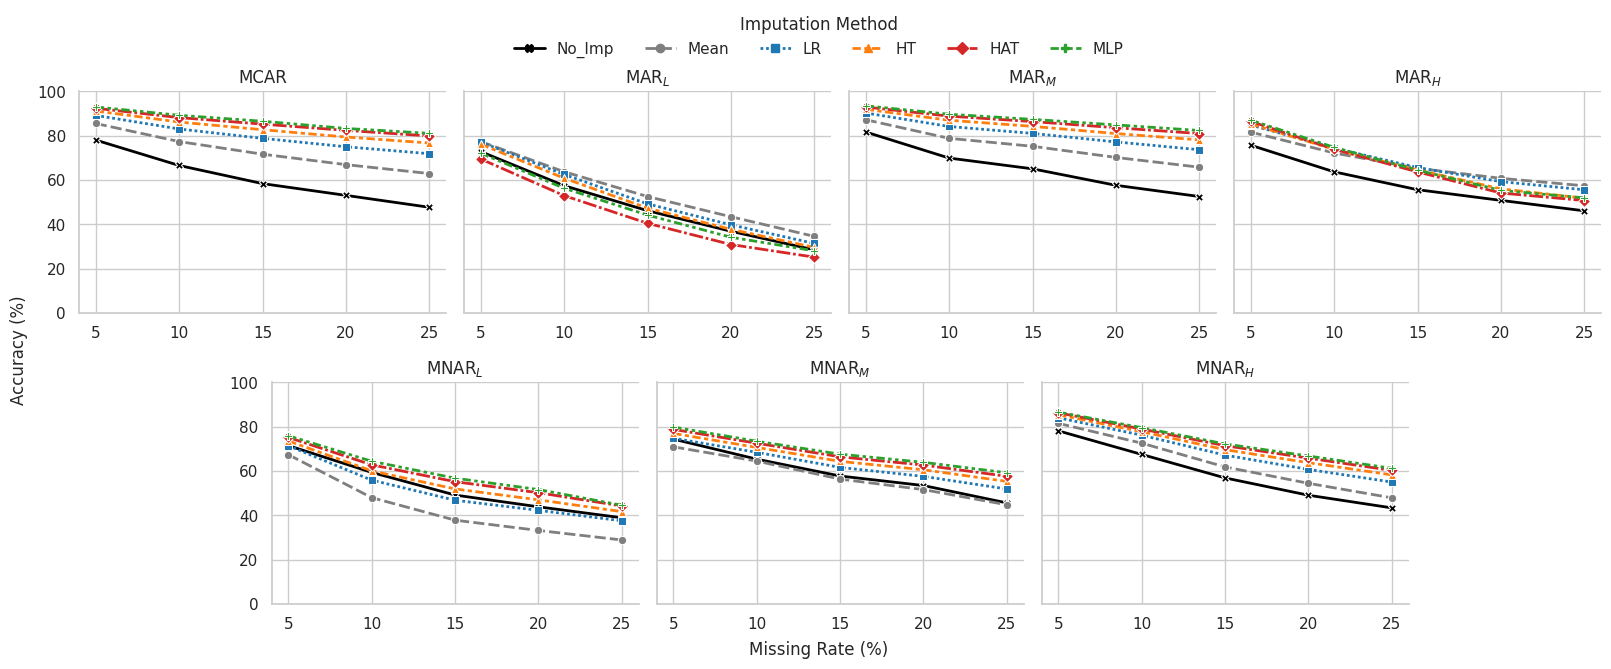

In [8]:
sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=df,
    x="MR",
    y="Accuracy",
    hue="Imputation_Method",
    style="Imputation_Method",
    markers=imp_markers,
    palette=imp_colors,
    col="Mechanism",
    col_wrap=4,
    kind="line",
    linewidth=2,
    estimator="mean",
    errorbar="sd",
    height=3.0,
    aspect=1.0,
    facet_kws={"sharex": False}

)

g.figure.set_size_inches(16, 6)


# --- Captura legenda criada automaticamente ---
handles, labels = g.legend.legend_handles, [t.get_text() for t in g.legend.texts]

# Remove legenda antiga (a correta)
g.legend.remove()

# Cria legenda nova no topo
g.fig.legend(
    handles,
    labels,
    title="Imputation Method",
    loc="upper center",
    ncol=len(labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.08)
)

# --- Labels centralizados ---
g.set_axis_labels("", "")
g.fig.text(0.5, 0.00, "Missing Rate (%)", ha="center", va="center")
g.fig.text(0.00, 0.5, "Accuracy (%)", ha="center", va="center", rotation="vertical")

# --- Ajuste títulos ---
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    title = ax.get_title()
    ax.set_title(mec_labels.get(title, title))

g.set(ylim=(0, 100))

plt.tight_layout()


ncols = 4  # mesmo valor do col_wrap
axes = g.axes.flatten()
nplots = len(axes)

remainder = nplots % ncols

if remainder != 0:
    last_axes = axes[-remainder:]

    # posição da primeira linha (referência)
    ref_left = axes[0].get_position().x0
    ref_right = axes[ncols - 1].get_position().x1
    full_width = ref_right - ref_left

    # largura atual da última linha
    cur_left = last_axes[0].get_position().x0
    cur_right = last_axes[-1].get_position().x1
    cur_width = cur_right - cur_left

    # deslocamento necessário
    shift = (full_width - cur_width) / 2

    for ax in last_axes:
        pos = ax.get_position()
        ax.set_position([
            pos.x0 + shift,
            pos.y0,
            pos.width,
            pos.height
        ])

plt.savefig("imputers_ad.png", dpi=300, bbox_inches='tight')
plt.show()

CD Diagram

In [ ]:
from cd_diagram import draw_cd_diagram

df = pd.read_csv("results_rhr_patient.csv")

df['Imputation_Method'] = df['Imputation_Method'].fillna('No_Imp')

mechanisms = df['Mechanism'].unique()
mec_labels = {}
for mec in mechanisms:
    if "_" in mec:
        base, sub = mec.split("_", 1)
        mec_labels[mec] = rf"{base}$_{{{sub.upper()}}}$"
    else:
        mec_labels[mec] = mec

metric = "Accuracy"
df_crit= df.groupby(['Mechanism', "Patient", 'MR', 'Imputation_Method'])[metric].mean().reset_index()
df_crit['dataset_name'] = df_crit['Mechanism'] + '_' + df_crit['Patient'] + '_' + df_crit['MR'].astype(str)
df_crit = df_crit.rename(columns={'Imputation_Method': 'classifier_name'})
df_crit = df_crit.rename(columns={metric: 'accuracy'})
df_crit = df_crit.drop(columns=['MR'])
df_crit = df_crit[['classifier_name', 'dataset_name', 'accuracy', 'Mechanism']]
print(df_crit.shape)

(6300, 4)


In [5]:
dfs = {}

for mec in df_crit['Mechanism'].unique():
    dfs[mec] = df_crit[df_crit['Mechanism'] == mec].drop(columns=['Mechanism'])

for mec, df_mec in dfs.items():
    try:
        draw_cd_diagram(df_perf=df_mec, title=f"{mec_labels[mec]}", labels=False, save_path=f"Plots/CD_Diagrams/CD-AD-{mec}.png")
    except Exception as e:
        print(f"Error processing {mec}: {e}")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

['HAT' 'HT' 'LR' 'MLP' 'Mean' 'No_Imp']
HAT       11.0
HT        10.0
LR        27.0
MLP       35.0
Mean      46.0
No_Imp     6.0
dtype: float64
No_Imp    5.006667
HT        3.903333
HAT       3.873333
LR        2.780000
MLP       2.736667
Mean      2.700000
dtype: float64
('Mean', 'No_Imp', np.float64(3.025167648515144e-23), True)
('MLP', 'No_Imp', np.float64(1.5359087866276318e-15), True)
('LR', 'No_Imp', np.float64(9.589277401742193e-13), True)
('HT', 'MLP', np.float64(2.53018671681501e-12), True)
('HT', 'LR', np.float64(2.5378653205655038e-11), True)
('HAT', 'LR', np.float64(4.3677678742997593e-10), True)
('HAT', 'MLP', np.float64(9.983206877656823e-09), True)
('HT', 'Mean', np.float64(1.157484576989588e-08), True)
('HAT', 'Mean', np.float64(5.1208508497184306e-08), True)
('HAT', 'No_Imp', np.float64(6.281540348653047e-07), True)
('HT', 'No_Imp', np.float64(5.712801530846763e-06), True)
('LR', 'MLP', np.float64(0.010250323103496087), True)
('LR', 'Mean', np.float64(0.01522147149605

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

['HAT' 'HT' 'LR' 'MLP' 'Mean' 'No_Imp']
HAT        2.0
HT        15.0
LR        25.0
MLP       44.0
Mean      47.0
No_Imp     9.0
dtype: float64
HAT       5.296667
No_Imp    3.966667
HT        3.813333
LR        3.236667
Mean      2.480000
MLP       2.206667
dtype: float64
('HAT', 'MLP', np.float64(3.877852286197811e-24), True)
('HAT', 'Mean', np.float64(1.1374344629399497e-22), True)
('HAT', 'LR', np.float64(7.278579578172042e-20), True)
('HAT', 'HT', np.float64(3.1787344368434577e-19), True)
('HAT', 'No_Imp', np.float64(3.498117982755121e-17), True)
('MLP', 'No_Imp', np.float64(9.131919521415557e-15), True)
('HT', 'MLP', np.float64(5.132182189741383e-14), True)
('Mean', 'No_Imp', np.float64(1.5080806821585648e-11), True)
('HT', 'Mean', np.float64(2.1796810724008098e-10), True)
('LR', 'MLP', np.float64(1.0223237957435598e-08), True)
('LR', 'Mean', np.float64(2.2363309140631596e-06), True)
('HT', 'LR', np.float64(0.004396072703843025), True)
('LR', 'No_Imp', np.float64(0.02587622855744

...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

['HAT' 'HT' 'LR' 'MLP' 'Mean' 'No_Imp']
HAT       37.0
HT        19.0
LR        23.0
MLP       21.0
Mean       9.0
No_Imp    11.0
dtype: float64
Mean      5.000000
No_Imp    4.403333
MLP       3.276667
HT        3.016667
LR        2.766667
HAT       2.536667
dtype: float64
('HAT', 'Mean', np.float64(8.522396571505005e-21), True)
('HT', 'Mean', np.float64(3.074672447743475e-20), True)
('MLP', 'Mean', np.float64(2.24604895496019e-19), True)
('LR', 'Mean', np.float64(2.7715310228964823e-19), True)
('HAT', 'No_Imp', np.float64(1.674644665069933e-17), True)
('HT', 'No_Imp', np.float64(1.1061949432217017e-15), True)
('LR', 'No_Imp', np.float64(2.159029316278491e-15), True)
('MLP', 'No_Imp', np.float64(1.2082490335265487e-12), True)
('Mean', 'No_Imp', np.float64(8.91945531759913e-09), True)
('HAT', 'MLP', np.float64(2.7470647310766844e-06), True)
('LR', 'MLP', np.float64(0.0001504514037907211), True)
('HAT', 'HT', np.float64(0.0016158191313058118), True)
('HT', 'LR', np.float64(0.015666399700

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

['HAT' 'HT' 'LR' 'MLP' 'Mean' 'No_Imp']
HAT       42.0
HT        11.0
LR        10.0
MLP       34.0
Mean       5.0
No_Imp     7.0
dtype: float64
No_Imp    5.070000
Mean      4.866667
LR        2.956667
HT        2.910000
MLP       2.876667
HAT       2.320000
dtype: float64
('HAT', 'No_Imp', np.float64(2.6172837818301605e-24), True)
('HT', 'No_Imp', np.float64(6.573101863808704e-24), True)
('MLP', 'No_Imp', np.float64(3.754383142143857e-23), True)
('LR', 'No_Imp', np.float64(6.12750470171843e-22), True)
('MLP', 'Mean', np.float64(3.891285180536674e-21), True)
('HAT', 'Mean', np.float64(4.909075191541249e-21), True)
('HT', 'Mean', np.float64(2.2460483905426847e-19), True)
('LR', 'Mean', np.float64(3.4663511156656474e-18), True)
('HAT', 'LR', np.float64(2.6491726550198814e-07), True)
('HAT', 'HT', np.float64(1.1049838535891305e-06), True)
('HAT', 'MLP', np.float64(0.01876499391151532), False)
('HT', 'MLP', np.float64(0.37000440632106657), False)
('HT', 'LR', np.float64(0.526512959622202),

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

In [6]:
from PIL import Image

# List of CD diagram images in order
image_files = [f"Plots/CD_Diagrams/CD-AD-{mec}.png" for mec in mechanisms]

# Open all images
images = [Image.open(img_file) for img_file in image_files]

# Get dimensions
widths, heights = zip(*(img.size for img in images))

# Calculate total height and max width
total_height = sum(heights)
max_width = max(widths)

# Create new image with combined height
combined_image = Image.new('RGB', (max_width, total_height), 'white')

# Paste images one below the other
y_offset = 0
for img in images:
    combined_image.paste(img, (0, y_offset))
    y_offset += img.size[1]

# Save combined image
combined_image.save('Plots/CD_Diagrams/CD-AD-all.png')
print("Combined image saved as CD-AD-all.png")

Combined image saved as CD-AD-all.png
